In [16]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
load_dotenv()

True

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
model = ChatGroq(model='llama-3.3-70b-versatile')

In [19]:
def chatbot(state: ChatState) -> dict:

        messages = state['messages']
        response = model.invoke(messages)
        return {'messages': response}

In [20]:
graph = StateGraph(ChatState)
checkpointer = MemorySaver()    #Used to save the state in RAM

graph.add_node('chatbot', chatbot)

graph.add_edge(START, 'chatbot')
graph.add_edge('chatbot', END)

chatbot = graph.compile(checkpointer=checkpointer)

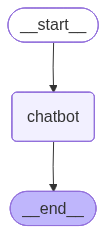

In [21]:
chatbot

In [27]:
thread_id = '1'

initial_state = {
    'messages': [
        HumanMessage(content='Hello, how are you?')
    ]
}

config = {
    'configurable': {
        'thread_id': thread_id
    }
}

response = chatbot.invoke(initial_state, config=config)

response

{'messages': [HumanMessage(content='my name is aniket', additional_kwargs={}, response_metadata={}, id='73f52104-a14f-4802-afd9-ed84effb3ab0'),
  AIMessage(content="Hello Aniket, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 41, 'total_tokens': 69, 'completion_time': 0.056755106, 'completion_tokens_details': None, 'prompt_time': 0.01158349, 'prompt_tokens_details': None, 'queue_time': 0.161943369, 'total_time': 0.068338596}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4122-10fe-7bb0-a5d6-4566adbbcd54-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 28, 'total_tokens': 69}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_meta

In [23]:
thread_id = '1'

while True:

    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit']:
        print("Exiting the chatbot. Goodbye!")
        break

    
    config = {
        'configurable': {
            'thread_id': thread_id
        }
    }

    # Get the chatbot's response
    response = chatbot.invoke({ 'messages': [ HumanMessage(content=user_input) ] }, config=config)

    # Print the chatbot's response
    print(f"Chatbot: {response['messages'][-1].content}")

Chatbot: Hello Aniket, it's nice to meet you. Is there something I can help you with or would you like to chat?
Chatbot: Your name is Aniket.
Chatbot: 100 + 20 = 120
Chatbot: We had 120 earlier. 

120 + 9 = 129
Exiting the chatbot. Goodbye!


In [24]:
response

{'messages': [HumanMessage(content='my name is aniket', additional_kwargs={}, response_metadata={}, id='73f52104-a14f-4802-afd9-ed84effb3ab0'),
  AIMessage(content="Hello Aniket, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 41, 'total_tokens': 69, 'completion_time': 0.056755106, 'completion_tokens_details': None, 'prompt_time': 0.01158349, 'prompt_tokens_details': None, 'queue_time': 0.161943369, 'total_time': 0.068338596}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4122-10fe-7bb0-a5d6-4566adbbcd54-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 28, 'total_tokens': 69}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_meta